In [5]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# ── Kết nối DuckDB → PostgreSQL ───────────────────────────────────────────────
PG = "dbname=risk_banking user=namphuong password=2104 host=localhost port=5432"
conn = duckdb.connect()
conn.execute("INSTALL postgres_scanner; LOAD postgres_scanner;")
conn.execute(f"ATTACH '{PG}' AS pg (TYPE postgres);")

# ── Style cho chart ───────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "font.size":        11,
    "axes.titlesize":   13,
    "axes.titleweight": "bold",
})
COLORS = {
    "navy":   "#1D4E89", "blue":  "#2E86AB",
    "teal":   "#1D9E75", "green": "#27AE60",
    "amber":  "#E67E22", "red":   "#C0392B",
    "purple": "#8E44AD", "gray":  "#5D6D7E",
}
print("✓ Kết nối thành công — sẵn sàng phân tích")

✓ Kết nối thành công — sẵn sàng phân tích


## 5.1 — Rejection Rate theo tháng

In [6]:
df_rej = conn.execute("""
    WITH acc AS (
        SELECT issue_month AS period, COUNT(*) AS acc_count,
            ROUND(AVG(fico_range_low), 2) AS avg_fico,
            ROUND(AVG(dti), 2) AS avg_dti
        FROM pg.accepted_loans WHERE issue_month IS NOT NULL
        GROUP BY issue_month
    ),
    rej AS (
        SELECT application_month AS period, COUNT(*) AS rej_count,
            ROUND(AVG(CAST(risk_score AS DOUBLE)), 2) AS avg_risk_score
        FROM pg.rejected_loans WHERE application_month IS NOT NULL
        GROUP BY application_month
    )
    SELECT COALESCE(a.period, r.period) AS period,
        COALESCE(a.acc_count, 0) AS accepted,
        COALESCE(r.rej_count, 0) AS rejected,
        COALESCE(a.acc_count,0)+COALESCE(r.rej_count,0) AS total,
        ROUND(100.0 * COALESCE(r.rej_count,0)
            / NULLIF(COALESCE(a.acc_count,0)+COALESCE(r.rej_count,0),0), 2) AS rejection_rate_pct,
        a.avg_fico, r.avg_risk_score,
        ROUND(a.avg_fico - r.avg_risk_score, 2) AS fico_gap,
        a.avg_dti
    FROM acc a FULL OUTER JOIN rej r ON a.period = r.period
    WHERE COALESCE(a.period, r.period) IS NOT NULL
    ORDER BY period
""").df()

print(f"Rejection Rate trung bình: {df_rej.rejection_rate_pct.mean():.1f}%")
print(f"Rejection Rate cao nhất:   {df_rej.rejection_rate_pct.max():.1f}% tháng {df_rej.loc[df_rej.rejection_rate_pct.idxmax(),'period']}")
df_rej.head(10)


MIN_VOLUME = 100
df_rej_clean = df_rej[df_rej["total"] >= MIN_VOLUME].copy()
df_rej_clean = df_rej_clean[df_rej_clean["period"].notna()].copy()

n_removed = len(df_rej) - len(df_rej_clean)
print(f"  Rejection Rate trung bình: {df_rej_clean['rejection_rate_pct'].mean():.1f}%")
print(f"  Rejection Rate cao nhất: {df_rej_clean['rejection_rate_pct'].max():.1f}%")


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rejection Rate trung bình: 89.3%
Rejection Rate cao nhất:   100.0% tháng 2007-05
  Rejection Rate trung bình: 89.9%
  Rejection Rate cao nhất: 95.5%


Rejection Rate TB: 90.0%
Rejection Rate Max: 95.5%
Rejection Rate Min: 71.0%


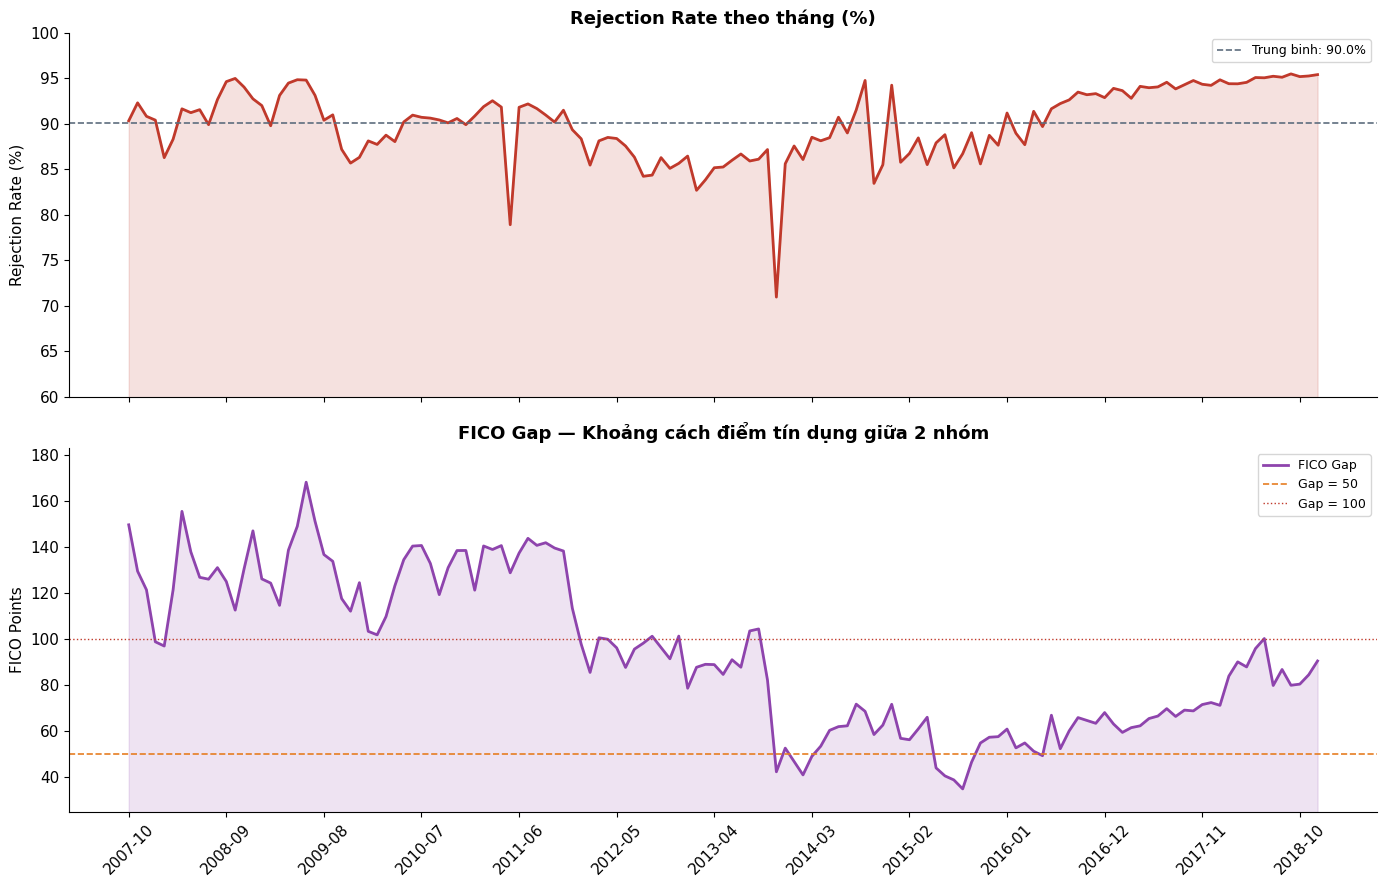

In [9]:
import numpy as np

TAIL_MIN_VOLUME = 500
df_chart = df_rej_clean[df_rej_clean["total"] >= TAIL_MIN_VOLUME].copy()

n_tail = len(df_rej_clean) - len(df_chart)
print(f"Rejection Rate TB: {df_chart['rejection_rate_pct'].mean():.1f}%")
print(f"Rejection Rate Max: {df_chart['rejection_rate_pct'].max():.1f}%")
print(f"Rejection Rate Min: {df_chart['rejection_rate_pct'].min():.1f}%")

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# Chart 1: Rejection Rate — dung df_chart (da loc ca head va tail)
axes[0].plot(df_chart["period"], df_chart["rejection_rate_pct"],
             color=COLORS["red"], linewidth=2)
axes[0].fill_between(df_chart["period"], df_chart["rejection_rate_pct"],
                     alpha=0.15, color=COLORS["red"])
axes[0].set_title("Rejection Rate theo tháng (%)")
axes[0].set_ylabel("Rejection Rate (%)")
axes[0].set_ylim(60, 100)  # zoom de thay ro bien dong
mean_rej = df_chart["rejection_rate_pct"].mean()
axes[0].axhline(mean_rej, color=COLORS["gray"], linestyle="--",
                linewidth=1.2, label=f"Trung binh: {mean_rej:.1f}%")
axes[0].legend(fontsize=9)

gap_clean = df_chart["fico_gap"].dropna()
ymin = max(0, gap_clean.min() - 10)
ymax = gap_clean.max() + 15
axes[1].plot(df_chart["period"], df_chart["fico_gap"],
             color=COLORS["purple"], linewidth=2, label="FICO Gap")
axes[1].fill_between(df_chart["period"], df_chart["fico_gap"],
                     alpha=0.15, color=COLORS["purple"])

axes[1].axhline(50, color=COLORS["amber"], linestyle="--", linewidth=1.2,
                label="Gap = 50")
axes[1].axhline(100, color=COLORS["red"], linestyle=":", linewidth=1.0,
                label="Gap = 100")
axes[1].set_title("FICO Gap — Khoảng cách điểm tín dụng giữa 2 nhóm")
axes[1].set_ylabel("FICO Points")
axes[1].set_ylim(ymin, ymax)  # Zoom vao vung gap thuc te
axes[1].legend(fontsize=9)

step = max(1, len(df_chart)//12)
axes[1].set_xticks(df_chart["period"][::step])
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("results/m5_rejection_rate.png", dpi=150, bbox_inches="tight")
plt.show()


## 5.2 — Risk Score Gap theo State

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

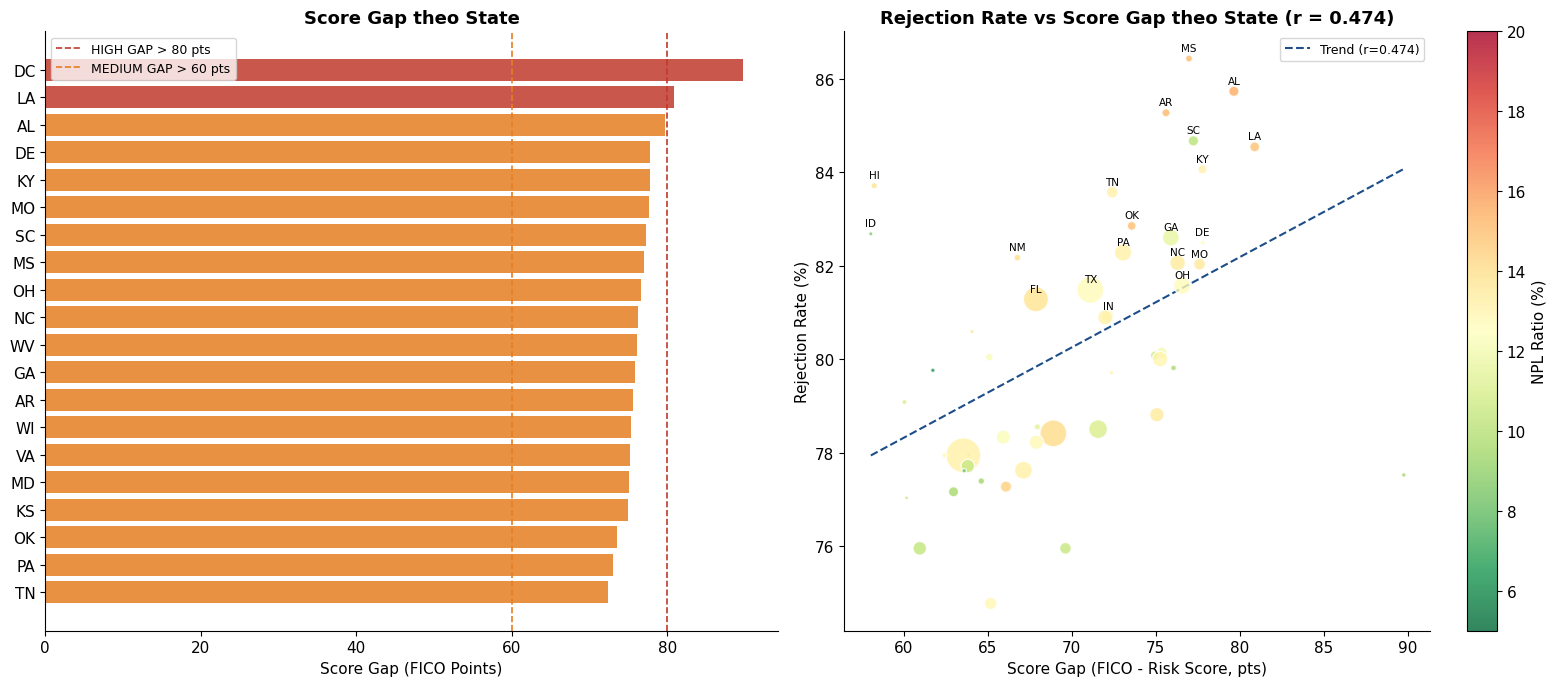

state  avg_fico  avg_risk_score  score_gap  acc_count  rej_count  rej_rate_pct  npl_pct
   DC    700.50          610.74      89.76       5356      18470         77.52     9.34
   LA    700.14          619.25      80.89      25759     140855         84.54    14.93
   AL    698.08          618.43      79.65      27284     163914         85.73    15.49
   DE    698.86          621.07      77.79       6458      30420         82.49    12.40
   KY    699.01          621.23      77.78      21887     115427         84.06    13.15
   MO    699.68          622.07      77.61      36084     164679         82.03    13.59
   SC    698.78          621.54      77.24      28003     154613         84.67    10.15
   MS    697.24          620.26      76.98      12639      80518         86.43    15.23
   OH    698.53          621.95      76.58      75132     332536         81.57    12.71
   NC    698.85          622.55      76.30      62730     286948         82.06    13.50
   WV    700.89          624.83 

In [8]:
df_gap = conn.execute("""
    WITH acc AS (
        SELECT addr_state AS state,
            ROUND(AVG(fico_range_low), 2) AS avg_fico,
            COUNT(*) AS acc_count,
            ROUND(100.0*SUM(CASE WHEN debt_group>=3 THEN 1 ELSE 0 END)/COUNT(*),2) AS npl_pct
        FROM pg.accepted_loans WHERE addr_state IS NOT NULL GROUP BY addr_state
    ),
    rej AS (
        SELECT state,
            ROUND(AVG(CAST(risk_score AS DOUBLE)), 2) AS avg_risk_score,
            COUNT(*) AS rej_count
        FROM pg.rejected_loans WHERE state IS NOT NULL AND risk_score IS NOT NULL
        GROUP BY state
    )
    SELECT a.state, a.avg_fico, r.avg_risk_score,
        ROUND(a.avg_fico - r.avg_risk_score, 2) AS score_gap,
        a.acc_count, r.rej_count,
        ROUND(100.0*r.rej_count/NULLIF(a.acc_count+r.rej_count,0),2) AS rej_rate_pct,
        a.npl_pct
    FROM acc a LEFT JOIN rej r ON a.state = r.state
    WHERE r.avg_risk_score IS NOT NULL
    ORDER BY rej_rate_pct DESC
""").df()


MIN_ACC = 1000
df_gap_valid = df_gap[df_gap["acc_count"] >= MIN_ACC].copy()
n_excluded = len(df_gap) - len(df_gap_valid)


df_gap_plot = df_gap_valid.sort_values("score_gap", ascending=False).head(20)

import numpy as np
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Chart trai: Score Gap theo state
colors_gap = [COLORS["red"] if g > 80 else COLORS["amber"] if g > 60 else COLORS["teal"]
              for g in df_gap_plot["score_gap"]]
axes[0].barh(df_gap_plot["state"][::-1], df_gap_plot["score_gap"][::-1],
             color=colors_gap[::-1], alpha=0.85)
axes[0].axvline(80, color=COLORS["red"],   linestyle="--", linewidth=1.2,
                label="HIGH GAP > 80 pts")
axes[0].axvline(60, color=COLORS["amber"], linestyle="--", linewidth=1.2,
                label="MEDIUM GAP > 60 pts")
axes[0].set_title("Score Gap theo State")
axes[0].set_xlabel("Score Gap (FICO Points)")
axes[0].legend(fontsize=9)

# Chart phai: Rejection Rate vs Score Gap scatter
sc = axes[1].scatter(df_gap_valid["score_gap"], df_gap_valid["rej_rate_pct"],
                     s=df_gap_valid["acc_count"]/500,
                     c=df_gap_valid["npl_pct"], cmap="RdYlGn_r",
                     vmin=5, vmax=20, alpha=0.8, edgecolors="white", zorder=3)
for _, row in df_gap_valid.head(20).iterrows():
    axes[1].annotate(row["state"], (row["score_gap"], row["rej_rate_pct"]),
                     fontsize=7.5, ha="center", va="bottom",
                     xytext=(0, 4), textcoords="offset points")
if len(df_gap_valid) > 2:
    from scipy import stats as sp_stats
    slope, intercept, r_sg, _, _ = sp_stats.linregress(
        df_gap_valid["score_gap"], df_gap_valid["rej_rate_pct"])
    x_l = np.linspace(df_gap_valid["score_gap"].min(), df_gap_valid["score_gap"].max(), 100)
    axes[1].plot(x_l, slope*x_l+intercept, color=COLORS["navy"],
                 linestyle="--", linewidth=1.5, label=f"Trend (r={r_sg:.3f})")
    axes[1].legend(fontsize=9)
    axes[1].set_title(f"Rejection Rate vs Score Gap theo State (r = {r_sg:.3f})")
else:
    axes[1].set_title("Rejection Rate vs Score Gap theo State")
plt.colorbar(sc, ax=axes[1], label="NPL Ratio (%)")
axes[1].set_xlabel("Score Gap (FICO - Risk Score, pts)")
axes[1].set_ylabel("Rejection Rate (%)")

plt.tight_layout()
plt.savefig("results/m5_risk_score_gap.png", dpi=150, bbox_inches="tight")
plt.show()

print(df_gap_valid.sort_values("score_gap", ascending=False).head(20).to_string(index=False))